# Airbnb Market Analysis: Guest Behavior & Economic Impact
**Author:** Aakash | **Tools:** SQL · Python · Databricks  
**Dataset:** Synthetic Airbnb dataset — 7 US cities · 10K bookings · 32K spending transactions

---

## Project Goal
Analyze how guest demographics, travel behavior, and listing characteristics 
drive booking performance and local economic impact across 7 US markets.

This project applies a DMO (Destination Management Organization) lens to Airbnb platform data — 
asking not just *who books* but *how visitor behavior drives local economic outcomes*.

---


## Finding 1 — Revenue by City
Miami leads total completed booking revenue at **$1.27M** despite ranking 4th in total bookings (1,217).  
New York City generates similar revenue ($1.21M) with 32% more bookings (1,607) — 
indicating NYC guests book more frequently but at lower average value ($753 vs $1,040).

**Implication:** Miami is a high-yield, lower-volume market. NYC is a high-volume, moderate-yield market.  
These require different growth strategies — Miami needs supply expansion, NYC needs conversion optimization.


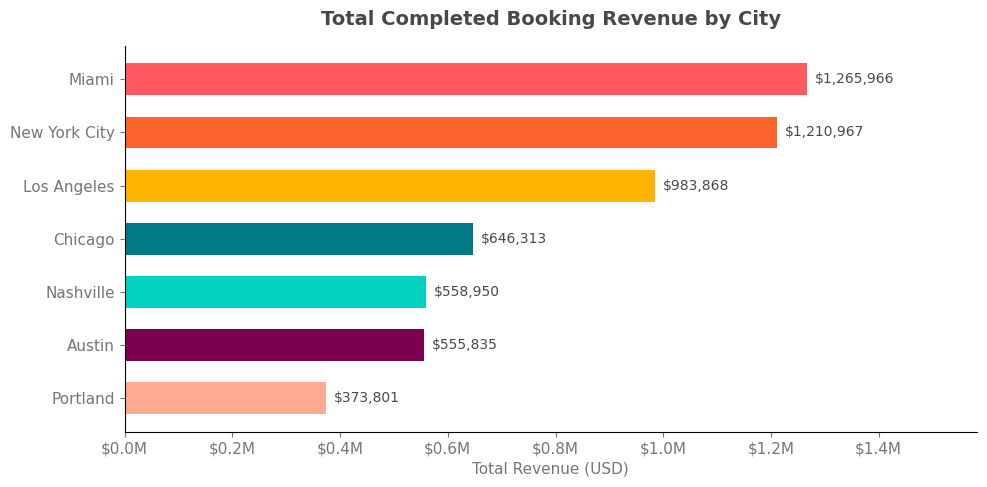

In [0]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

AIRBNB_RED   = "#FF5A5F"
AIRBNB_DARK  = "#484848"
AIRBNB_GRAY  = "#767676"
CITY_COLORS  = ["#FF5A5F","#FC642D","#FFB400","#007A87","#00D1C1","#7B0051","#FFAA91"]

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.labelcolor": AIRBNB_DARK, "xtick.color": AIRBNB_GRAY,
    "ytick.color": AIRBNB_GRAY, "font.family": "sans-serif", "font.size": 11,
})

revenue = spark.sql("""
    SELECT city, COUNT(*) AS total_bookings,
           ROUND(AVG(total_paid_usd), 2) AS avg_booking_value,
           ROUND(SUM(total_paid_usd), 0) AS total_revenue
    FROM airbnb.bookings WHERE booking_status = 'Completed'
    GROUP BY city ORDER BY total_revenue DESC
""").toPandas()

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(revenue["city"], revenue["total_revenue"],
               color=CITY_COLORS, edgecolor="none", height=0.6)
for bar, val in zip(bars, revenue["total_revenue"]):
    ax.text(bar.get_width() + 15000, bar.get_y() + bar.get_height()/2,
            f"${val:,.0f}", va="center", fontsize=10, color=AIRBNB_DARK)
ax.set_xlabel("Total Revenue (USD)", color=AIRBNB_GRAY)
ax.set_title("Total Completed Booking Revenue by City",
             fontsize=14, fontweight="bold", color=AIRBNB_DARK, pad=15)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x/1e6:.1f}M"))
ax.set_xlim(0, revenue["total_revenue"].max() * 1.25)
ax.invert_yaxis()
plt.tight_layout()
plt.show()


## Finding 2 — Cancellation Rates
Cancellation rates are remarkably consistent across markets (16–19%), 
with Miami the most reliable at **16.2%** and Austin the highest at **18.9%**.  
The tight range suggests platform-level factors (cancellation policies, guest screening) 
dominate over market-specific factors.

**Implication:** No single city has a retention crisis. 
Interventions should focus on the ~18% baseline across all markets.


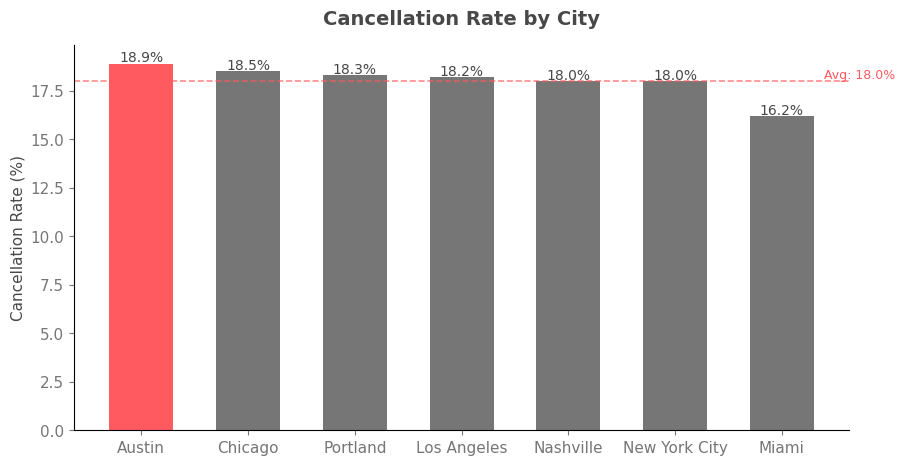

---------------------------------------------------------------------------
TypeError                                 Traceback (most recent call last)
File <command-6416742367592343>, line 24
     21 ax.set_ylabel("Cancellation Rate (%)")
     22 ax.set_title("Cancellation Rate by City",
     23              fontsize=14, fontweight="bold", color=AIRBNB_DARK, pad=15)
---> 24 ax.set_ylim(0, cancellation["cancellation_rate_pct"].max() * 1.2)
     25 plt.tight_layout()
     26 plt.show()

TypeError: unsupported operand type(s) for *: 'decimal.Decimal' and 'float'

In [0]:
cancellation = spark.sql("""
    SELECT city,
           ROUND(100.0 * SUM(CASE WHEN booking_status LIKE 'Cancelled%' THEN 1 ELSE 0 END) / COUNT(*), 1) 
           AS cancellation_rate_pct
    FROM airbnb.bookings GROUP BY city ORDER BY cancellation_rate_pct DESC
""").toPandas()

fig, ax = plt.subplots(figsize=(10, 5))
colors = [AIRBNB_RED if x == cancellation["cancellation_rate_pct"].max()
          else AIRBNB_GRAY for x in cancellation["cancellation_rate_pct"]]
bars = ax.bar(cancellation["city"], cancellation["cancellation_rate_pct"],
              color=colors, edgecolor="none", width=0.6)
ax.axhline(y=cancellation["cancellation_rate_pct"].mean(),
           color=AIRBNB_RED, linestyle="--", linewidth=1.2, alpha=0.7)
ax.text(6.4, cancellation["cancellation_rate_pct"].mean() + 0.1,
        f'Avg: {cancellation["cancellation_rate_pct"].mean():.1f}%',
        color=AIRBNB_RED, fontsize=9)
for bar, val in zip(bars, cancellation["cancellation_rate_pct"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f"{val}%", ha="center", fontsize=10, color=AIRBNB_DARK)
ax.set_ylabel("Cancellation Rate (%)")
ax.set_title("Cancellation Rate by City",
             fontsize=14, fontweight="bold", color=AIRBNB_DARK, pad=15)
ax.set_ylim(0, cancellation["cancellation_rate_pct"].max() * 1.2)
plt.tight_layout()
plt.show()


## Finding 3 — Travel Purpose: Spend vs Volume
Events/Festival travelers generate the **highest avg spend ($2,015)** but lowest volume (559 stays).  
Business travelers offer the best combination — 2nd highest spend ($1,852) with meaningful volume (1,429 stays).  
Leisure dominates volume (3,028 stays) but at the lowest avg spend among primary segments ($1,474).

**Implication:** Business + Events travelers represent ~20% of stays but ~28% of total spending — 
a disproportionate economic impact consistent with DMO research on high-yield visitor segments.


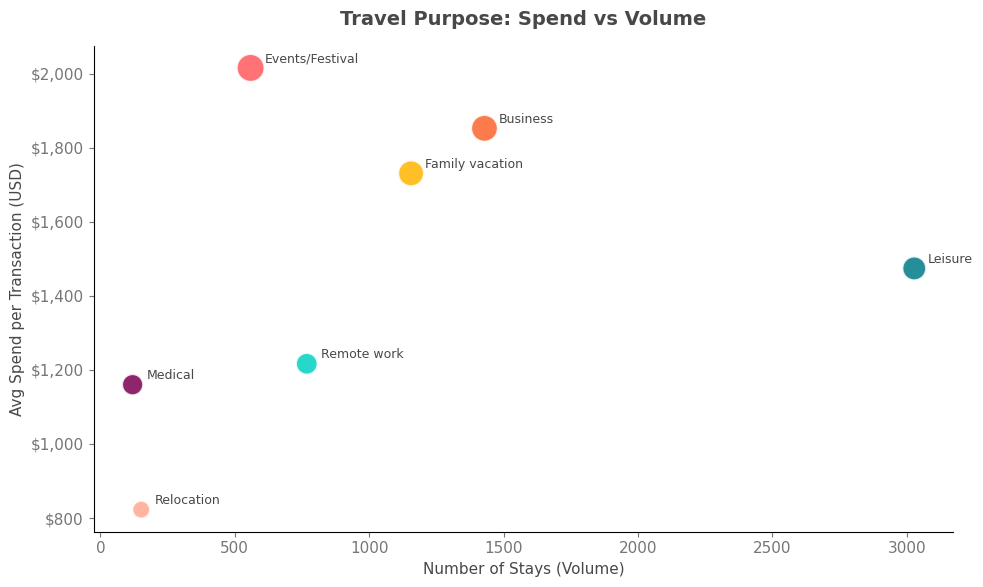

In [0]:
purpose_spend = spark.sql("""
    SELECT travel_purpose, ROUND(AVG(amount_usd), 2) AS avg_spend,
           COUNT(DISTINCT booking_id) AS stays
    FROM airbnb.spending GROUP BY travel_purpose ORDER BY avg_spend DESC
""").toPandas()

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(purpose_spend["stays"], purpose_spend["avg_spend"],
           s=purpose_spend["avg_spend"] / 5,
           c=CITY_COLORS[:len(purpose_spend)], alpha=0.85,
           edgecolors="white", linewidths=1.5)
for _, row in purpose_spend.iterrows():
    ax.annotate(row["travel_purpose"], (row["stays"], row["avg_spend"]),
                textcoords="offset points", xytext=(10, 4),
                fontsize=9, color=AIRBNB_DARK)
ax.set_xlabel("Number of Stays (Volume)")
ax.set_ylabel("Avg Spend per Transaction (USD)")
ax.set_title("Travel Purpose: Spend vs Volume",
             fontsize=14, fontweight="bold", color=AIRBNB_DARK, pad=15)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.show()


## Finding 4 — Spend per Night Heatmap
Shopping & Retail dominates per-night spending in NYC ($443) and Miami ($438).  
Dining & Restaurants is the most consistent high-spend category across all cities.  
Groceries & Markets is the lowest spend category universally — 
suggesting most Airbnb guests prefer eating out over self-catering.

**Implication:** Local retail and dining businesses benefit most from Airbnb-driven tourism. 
City tourism boards should prioritize partnerships with these sectors.


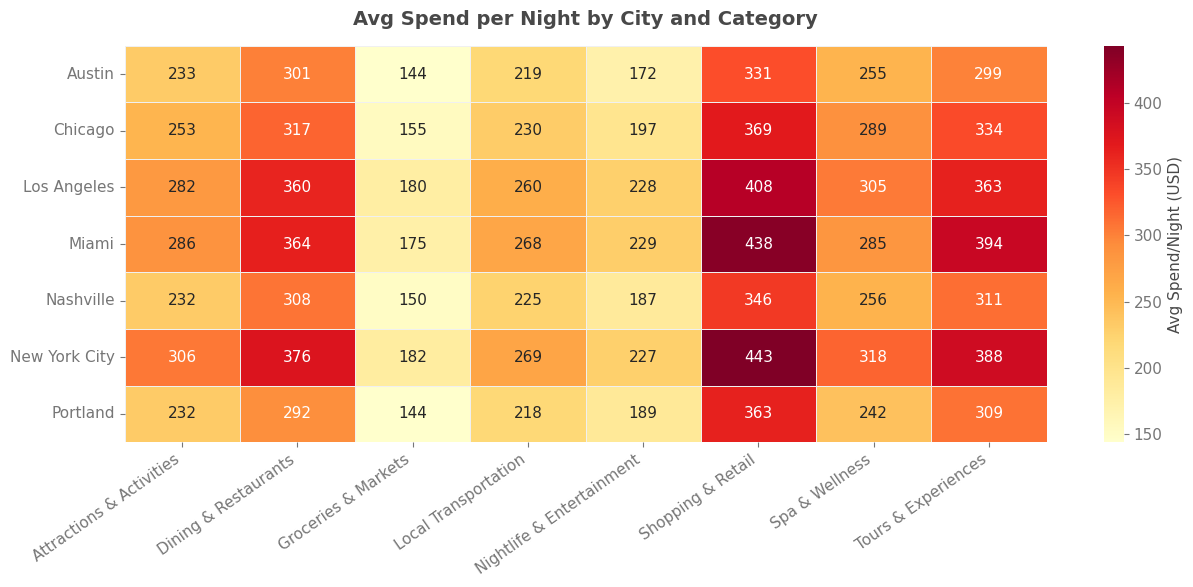

In [0]:
heatmap_data = spark.sql("""
    SELECT city, spend_category,
           ROUND(AVG(amount_usd / nights_stayed), 2) AS avg_spend_per_night
    FROM airbnb.spending GROUP BY city, spend_category
""").toPandas()

pivot = heatmap_data.pivot(index="city", columns="spend_category",
                            values="avg_spend_per_night")
fig, ax = plt.subplots(figsize=(13, 6))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlOrRd",
            linewidths=0.5, linecolor="#f0f0f0",
            cbar_kws={"label": "Avg Spend/Night (USD)"}, ax=ax)
ax.set_title("Avg Spend per Night by City and Category",
             fontsize=14, fontweight="bold", color=AIRBNB_DARK, pad=15)
ax.set_xlabel("")
ax.set_ylabel("")
plt.xticks(rotation=35, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## Finding 5 — Superhost Revenue Premium
Superhosts charge **$7.70 more per night** ($138 vs $130) and earn **$79 more per booking** ($834 vs $755).  
That's a **10.5% booking value premium** — meaningful given Airbnb's scale.

**Implication:** Superhost status functions as a quality signal that justifies price premiums.  
This suggests guests are willing to pay for trust and reliability — 
a key insight for host acquisition and retention strategy.


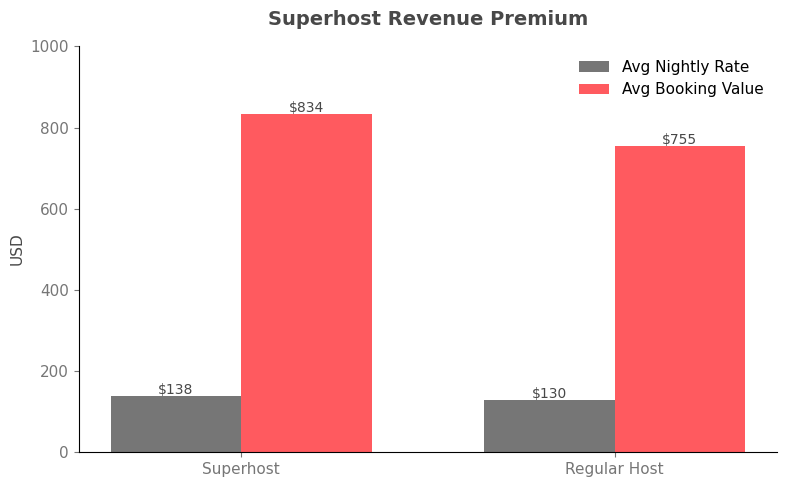

In [0]:
superhost = spark.sql("""
    SELECT h.superhost,
           ROUND(AVG(b.total_paid_usd), 2) AS avg_booking_value,
           ROUND(AVG(l.nightly_price_usd), 2) AS avg_nightly_rate
    FROM airbnb.bookings b
    JOIN airbnb.listings l ON b.listing_id = l.listing_id
    JOIN airbnb.hosts h ON l.host_id = h.host_id
    WHERE b.booking_status = 'Completed' GROUP BY h.superhost
""").toPandas()
superhost["label"] = superhost["superhost"].map({0: "Regular Host", 1: "Superhost"})

x = range(2)
width = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar([i - width/2 for i in x], superhost["avg_nightly_rate"],
               width, label="Avg Nightly Rate", color=AIRBNB_GRAY, edgecolor="none")
bars2 = ax.bar([i + width/2 for i in x], superhost["avg_booking_value"],
               width, label="Avg Booking Value", color=AIRBNB_RED, edgecolor="none")
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f"${bar.get_height():,.0f}", ha="center", fontsize=10, color=AIRBNB_DARK)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            f"${bar.get_height():,.0f}", ha="center", fontsize=10, color=AIRBNB_DARK)
ax.set_xticks(list(x))
ax.set_xticklabels(superhost["label"])
ax.set_ylabel("USD")
ax.set_title("Superhost Revenue Premium",
             fontsize=14, fontweight="bold", color=AIRBNB_DARK, pad=15)
ax.legend(frameon=False)
ax.set_ylim(0, superhost["avg_booking_value"].max() * 1.2)
plt.tight_layout()
plt.show()


---
## Key Takeaways

| Finding | Insight |
|---|---|
| Miami leads revenue | High avg booking value ($1,040) offsets lower volume |
| Cancellation rates uniform | Platform-level factors dominate (~18% across all cities) |
| Business/Events travelers | 20% of stays, ~28% of total spending |
| Shopping & Retail | Highest per-night spend in NYC ($443) and Miami ($438) |
| Superhost premium | 10.5% higher booking value — trust commands price premium |

---
## Next Steps — Phase 3: Causal Inference
- Does superhost status *cause* higher revenue or do better hosts self-select?
- Does longer booking lead time *cause* lower cancellation?
- Does longer stay *cause* more local economic impact?

*Tools: statsmodels · regression · difference-in-differences*
